<a href="https://colab.research.google.com/github/marianamq-a11y/Estatistica-mariana/blob/main/Tarefa05.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Grupo 2
Mariana Lopes Marques -14596593

Nayara Penati - 15677365

**2. Qual é o perfil dos alimentos presentes na base? Como você poderia representar a frequência das diferentes categorias de alimentos de maneira que fosse possível
compará-las?**

Resposta: a base é diversificada com maior dominancia em vegetais e produtos vegetais, frutas e sucos de frutas, cereais e massas e laticinios e ovos (proteina, gordula e sódio) apresentam grande variabilidade e assimetria positiva.
Utilizamos o grafico de barras para melhor visualização e comparação dos grupos de alimentos.


**10. O teor de sódio apresenta um comportamento semelhante ao observado para
proteína e gordura? Quais características da distribuição podem ser
identificadas?**

Resposta: O teor de sódio apresenta assimetria extrema a direita com a maioria dos alimentos concentrada em valores baixos e poucos alimentos com teores extremamente elevados, a gordura total ela segue um comportamento pareciso com a de assimetria positiva. Já a proteina apresenta uma distribuição mais equilibrada entre seus valores. Em numeros absolutos, o sódio atinge valores ordens de grandeza maiores que proteína e gordura por estar medido em miligramas, e não em gramas.



In [1]:
import pandas as pd

# Carregar a base de dados
try:
    df_usda = pd.read_excel('/content/usda_data.xlsx')
    print('Base de dados carregada com sucesso!')
except FileNotFoundError:
    print('Erro: O arquivo usda_data.xlsx não foi encontrado. Por favor, verifique o caminho do arquivo.')
    df_usda = None


Base de dados carregada com sucesso!


In [2]:
if df_usda is not None:
    print("Primeiras 5 linhas do DataFrame:")
    display(df_usda.head())
    print("\nInformações do DataFrame (colunas, tipos de dados e valores não nulos):")
    display(df_usda.info())


Primeiras 5 linhas do DataFrame:


,ID,Alimento,Categoria,Proteína (g),Gordura total (g),Sódio (mg),fdc_id
0,1,"Rúcula, baby, crua",Vegetais e Produtos Vegetais,1.648750,0.3250,86.93,2710822
1,2,"Aspargos verdes, crus",Vegetais e Produtos Vegetais,1.437500,0.2163,2.46,2710823
2,3,"Vagem, enlatada, embalagem comum, escorrida",Vegetais e Produtos Vegetais,1.040000,0.3900,282.00,321611
3,4,"Vagem, crua",Vegetais e Produtos Vegetais,1.968750,0.2750,0.00,2346400
4,5,"Folhas de beterraba, cruas",Vegetais e Produtos Vegetais,1.609375,0.1438,280.50,2747653



Informações do DataFrame (colunas, tipos de dados e valores não nulos):
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ID                 100 non-null    int64  
 1   Alimento           100 non-null    object 
 2   Categoria          100 non-null    object 
 3   Proteína (g)       100 non-null    float64
 4   Gordura total (g)  100 non-null    float64
 5   Sódio (mg)         100 non-null    float64
 6   fdc_id             100 non-null    int64  
dtypes: float64(3), int64(2), object(2)
memory usage: 5.6+ KB


None

In [5]:
# Analisando as categorias de alimentos
if df_usda is not None and 'Categoria' in df_usda.columns:
    print("Frequência das Categorias de Alimentos:")
    display(df_usda['Categoria'].value_counts().head(10)) # Exibe as 10 categorias mais frequentes
else:
    print("A coluna 'Categoria' não foi encontrada no DataFrame para análise de perfil.")

Frequência das Categorias de Alimentos:


,count
Categoria,
Vegetais e Produtos Vegetais,15
Frutas e Sucos de Frutas,15
Cereais e Massas,15
Laticínios e Ovos,15
Peixes e Frutos do Mar,10
Leguminosas e Produtos de Leguminosas,10
Carnes Bovinas,10
Carnes de Aves,10


In [6]:
# Analisando as estatísticas descritivas para componentes nutricionais chave
nutritional_columns_actual = ['Proteína (g)', 'Gordura total (g)', 'Sódio (mg)']

if df_usda is not None:
    existing_nutritional_columns = [col for col in nutritional_columns_actual if col in df_usda.columns]
    if existing_nutritional_columns:
        print("Estatísticas Descritivas para Componentes Nutricionais:")
        display(df_usda[existing_nutritional_columns].describe())
    else:
        print("Nenhuma das colunas nutricionais esperadas ('Proteína (g)', 'Gordura total (g)', 'Sódio (mg)') foi encontrada para estatísticas descritivas.")

Estatísticas Descritivas para Componentes Nutricionais:


,Proteína (g),Gordura total (g),Sódio (mg)
count,100.000000,100.000000,100.000000
mean,12.166630,6.880802,273.091411
std,9.198276,9.632325,665.830818
min,0.000000,0.100000,0.000000
25%,1.781250,0.380150,2.933250
50%,12.469720,2.066500,54.470000
75%,18.984768,8.286750,214.225000
max,32.100000,34.000000,5403.000000


/tmp/ipykernel_4993/3317095629.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_usda, y='Categoria', order=df_usda['Categoria'].value_counts().index, palette='viridis')


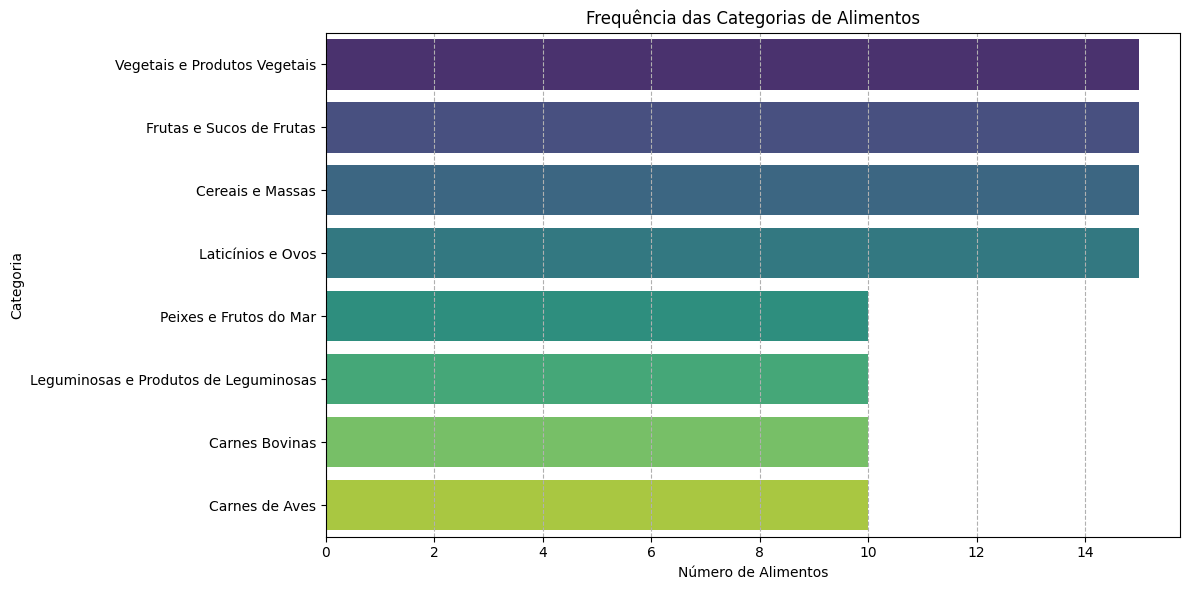

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

if df_usda is not None and 'Categoria' in df_usda.columns:
    plt.figure(figsize=(12, 6))
    sns.countplot(data=df_usda, y='Categoria', order=df_usda['Categoria'].value_counts().index, palette='viridis')
    plt.title('Frequência das Categorias de Alimentos')
    plt.xlabel('Número de Alimentos')
    plt.ylabel('Categoria')
    plt.grid(axis='x', linestyle='--')
    plt.tight_layout()
    plt.show()
else:
    print("Não foi possível gerar o gráfico de barras das categorias de alimentos. A coluna 'Categoria' não foi encontrada.")

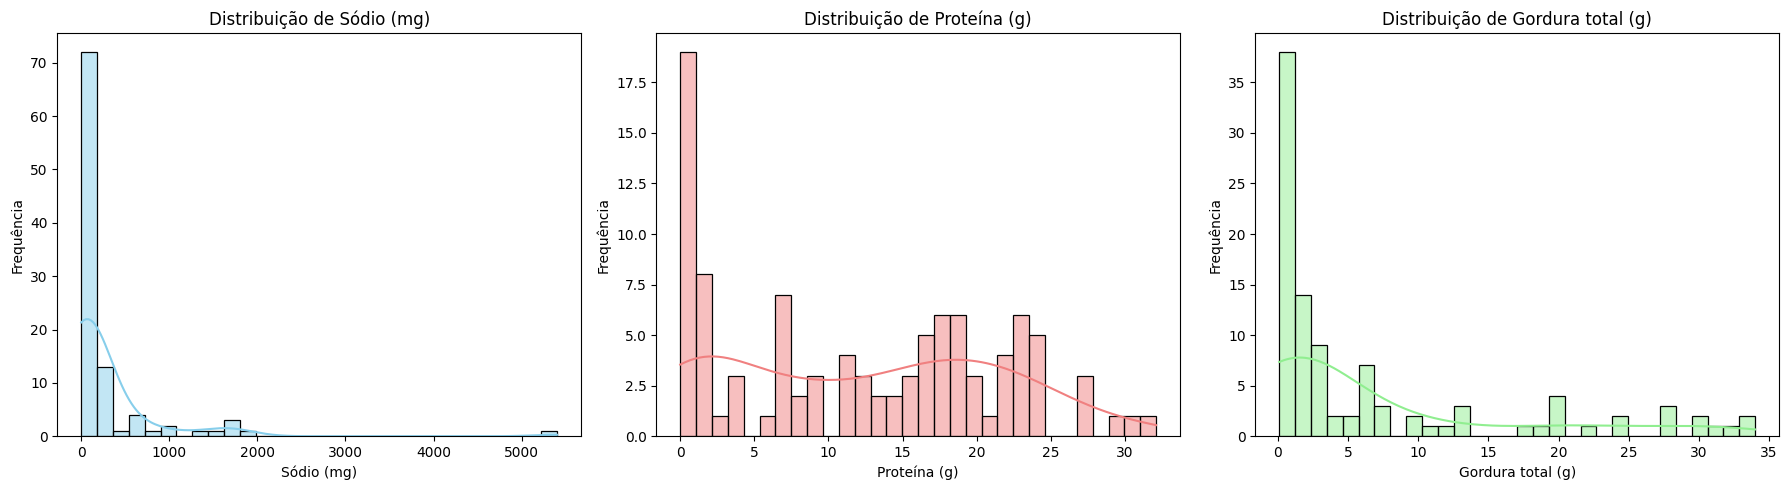


Matriz de Correlação entre Sódio, Proteína e Gordura:


,Sódio (mg),Proteína (g),Gordura total (g)
Sódio (mg),1.000000,0.388625,0.464909
Proteína (g),0.388625,1.000000,0.594458
Gordura total (g),0.464909,0.594458,1.000000


In [8]:
if df_usda is not None:
    # Histograms for Sodium, Protein, and Fat
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    sns.histplot(df_usda['Sódio (mg)'], bins=30, kde=True, ax=axes[0], color='skyblue')
    axes[0].set_title('Distribuição de Sódio (mg)')
    axes[0].set_xlabel('Sódio (mg)')
    axes[0].set_ylabel('Frequência')

    sns.histplot(df_usda['Proteína (g)'], bins=30, kde=True, ax=axes[1], color='lightcoral')
    axes[1].set_title('Distribuição de Proteína (g)')
    axes[1].set_xlabel('Proteína (g)')
    axes[1].set_ylabel('Frequência')

    sns.histplot(df_usda['Gordura total (g)'], bins=30, kde=True, ax=axes[2], color='lightgreen')
    axes[2].set_title('Distribuição de Gordura total (g)')
    axes[2].set_xlabel('Gordura total (g)')
    axes[2].set_ylabel('Frequência')

    plt.tight_layout()
    plt.show()

    # Correlation Matrix
    nutrients_for_corr = df_usda[['Sódio (mg)', 'Proteína (g)', 'Gordura total (g)']]
    correlation_matrix = nutrients_for_corr.corr()

    print("\nMatriz de Correlação entre Sódio, Proteína e Gordura:")
    display(correlation_matrix)
else:
    print("Não foi possível gerar os gráficos ou a matriz de correlação. O DataFrame não está disponível.")